<a href="https://colab.research.google.com/github/nehaj2026/undergrad_ml_assignments/blob/main/NJ_05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. **Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?**

General linear models are able to model complex and non-linear data that linear models are not able to. Linear models assume continuous and unbounded outcomes which is not compatible with probabilities that have bounds or categorical outcomes. General linear models are able to overcome this by applying activation functions that can bound predictions and deal with non-linear data. Thus, the general linear models allow for modeling a wider variety of outcome types rather than just continuous and unbounded outcomes.

2. **Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.**

Cross entropy is an effective loss function because it penalizes the model when predicting high probabilities for the wrong class, which forces the model to improve. Minimizing cross entropy is like maximizing the likelihood of the observed data. So, cross entropy finds the coefficients that make the actual outcomes most probable.

3. **True or false, and explain: Logistic regression is a linear model.**

True, logistic regression is considered a linear model since the decision boundary and latent variable is linear. However, the relationship between the predicted probability and the features is nonlinear.

4. **True or false, and explain: Logistic regression cannot be used for classification.**

False, logistic regression can be used for classification. The predicted probabilities are transformed to do hard prediction by putting a threshold for classification.

5. **Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?**

No, the coefficient in a logistic regression represents the change in the log-odds of the outcome for a 1 unit change in the feature/explanatory variable, holding other variables constant.

6. **True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.**

False, even though logistic regression applies a nonlinear activation function to the output, the latent variable is still linear in terms of features. So, the logistic regression cannot capture nonlinear relationships between features and log-odds. Feature engineering allows for new features and interactions to be created that can handle nonlinear data.

7. **True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.**

False, logistic regressions generally perform better when dealing with binary classification (predicts probabilities 0 to 1), linear models like OLS are the optimal choice for predicting a continuous variable. Because each of these model types are appropriate for different scenarios, a blanket statement like you should always use logistic regression is false.

In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Q1: Load the data, data.csv. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where Dropout corresponds to dropout and Graduate or Enrolled corresponds to not dropout.

In [ ]:
df = pd.read_csv('/content/undergrad_ml_assignments/data/data.csv', sep = ';')
columns = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[columns]

df.isnull().sum()
#No missing values

df = df.dropna()
df

#Binary variable creation
df['Dropout'] = np.where(df['Target'] == 'Dropout', 1, 0)
df

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0
...,...,...,...,...,...,...,...
4419,0,1,0,19,5,Graduate,0
4420,1,0,0,18,6,Dropout,1
4421,0,1,1,30,7,Dropout,1
4422,0,1,1,20,5,Graduate,0


Q2: Run a logistic regression of dropout status on Debtor, Tuition fees up to date, Scholarship holder, and Age at enrollment. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

In [ ]:
from sklearn.linear_model import LogisticRegression

X = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
y = df['Dropout']

model = LogisticRegression()
model.fit(df[X], y)

pd.DataFrame(zip(X, model.coef_[0]), columns = ['Variable', 'Coefficient'])

#Debtor and Age at enrollment predict a higher dropout probability
#Tuition fees up to date and Scholarship holder predict a lower dropout probability

#In particular, being up to date on tuition seems to greatly reduce dropout risk as compared to any of the other variables due to the large negative coefficient of -2.5565

,Variable,Coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


Q3: Use .predict_proba and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against Age at enrollment, hued by Tuition fees up to date. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

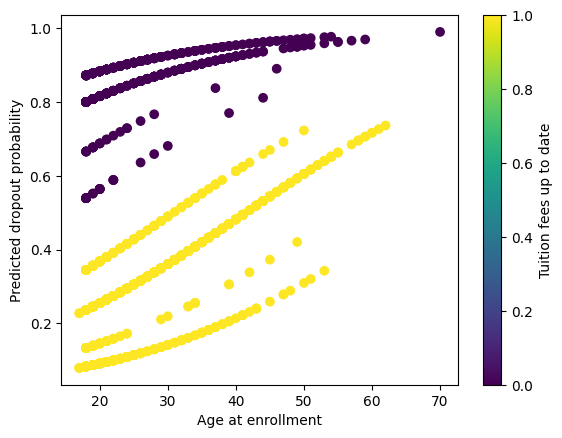

,Predicted dropout probability
Tuition fees up to date,
0,NaN
1,-0.612585


In [ ]:
import matplotlib.pyplot as plt

df['Predicted dropout probability'] = model.predict_proba(df[X])[:, 1]
plt.scatter(df['Age at enrollment'], df['Predicted dropout probability'], c = df['Tuition fees up to date'])
plt.xlabel('Age at enrollment')
plt.ylabel('Predicted dropout probability')
plt.colorbar(label = 'Tuition fees up to date')
plt.show()

Change_in_probability = df.groupby('Tuition fees up to date')['Predicted dropout probability'].mean().diff()
Change_in_probability

#At ages 50 and above being up to date on tuition reduces dropout probability the most

#On average, being up to date on tuition reduces the predicted probability of dropout by 61.3 percentage points

Q4: Use .predict and compute a confusion matrix for your classifier. What is the accuracy?

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

y_pred = model.predict(df[X])
print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

#The accuracy is 76.198%

[[2841  162]
 [ 891  530]]
0.7619801084990958


Q5: Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

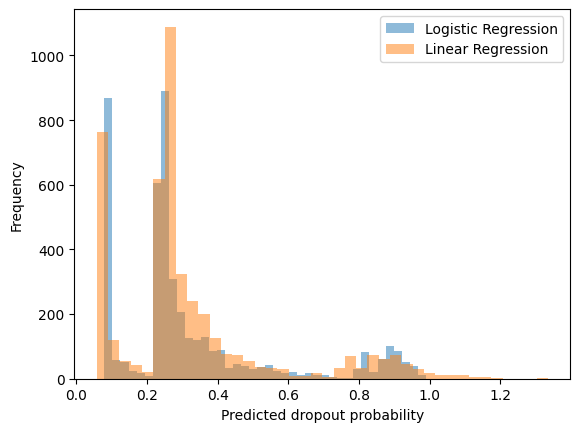

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[X], y)

df['Predicted dropout probability linear'] = model.predict(df[X])

#Histogram
plt.hist(df['Predicted dropout probability'], bins = 40, alpha = 0.5, label = 'Logistic Regression')
plt.hist(df['Predicted dropout probability linear'], bins = 40, alpha = 0.5, label = 'Linear Regression')
plt.legend()
plt.xlabel('Predicted dropout probability')
plt.ylabel('Frequency')
plt.show()

#The linear model is making some probability predictions greater than 1, which is not possible
#So, even though they both of similar predictions, I think logistic regression has better performance

**Q6: Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?**

The largest determinant of whether a student is at risk of dropping out is whether tuition was paid on time. If the student did not pay tuition on time, they are at significant risk of dropping out. In addition to this, students who have debt, do not have a scholarship, and are enrolled at an older age university have a higher risk of dropping out.

In order to help students stay enrolled, a few solutions would could be employed. First, increasing the number of scholarships could help reduce the likelihood of dropout for students that are otherwise high risk. Second, Reducing tuition on a staggered basis based on debt level or overall wealth would alleviate debt and likely improve tuition status and increase flexible payment for students.

Q7: Run a multinomial logistic regression of Target on Debtor, Tuition fees up to date, and Curricular units 1st sem (approved). Use .predict to make a hard classification, and compute a confusion matrix. Describe your results. Use .predict_proba to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [ ]:
from sklearn.linear_model import LogisticRegression

X = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
y = df['Target']

model = LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs')
model.fit(df[X], y)

y_pred = model.predict(df[X])
print(confusion_matrix(y, y_pred))

Predicted_probabilities = pd.DataFrame(model.predict_proba(df[X]), columns = model.classes_)
print(Predicted_probabilities)

#Overall, the hard classification seems to be placing a hard threshold in classification that has prevented enrolled from being predicted
#No, hard classification does not predict every class, as seen by the middle column being zero for the confusion matrix, which means enrolled was not predicted
#Yes, the predicted probabilities do predict every class as seen by each output having a probability assigned to all classes that is not zero


[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
       Dropout  Enrolled  Graduate
0     0.680547  0.210464  0.108989
1     0.695414  0.146043  0.158543
2     0.952988  0.041199  0.005813
3     0.117808  0.176983  0.705209
4     0.184227  0.212669  0.603104
...        ...       ...       ...
4419  0.184227  0.212669  0.603104
4420  0.784988  0.149758  0.065253
4421  0.071938  0.140644  0.787418
4422  0.184227  0.212669  0.603104
4423  0.117808  0.176983  0.705209

[4424 rows x 3 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

Q1: Load the data, cirrhosis.csv. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

In [ ]:
df = pd.read_csv('/content/undergrad_ml_assignments/data/cirrhosis.csv')
columns = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[columns]

df.isnull().sum()
#106 missing drug values, 6 missing stage values

df = df.dropna()
#Dropped missing values

df


,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL
...,...,...,...,...,...
307,0.4,N,D-penicillamine,2.0,C
308,0.4,N,Placebo,2.0,C
309,1.7,N,D-penicillamine,2.0,C
310,2.0,N,D-penicillamine,2.0,C


Q2: Run a logistic regression of Status on Edema, Drug, and Bilirubin. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

In [ ]:
from sklearn.linear_model import LogisticRegression

df['Status'] = np.where(df['Status'] == 'D', 1, 0)

X = ['Edema', 'Drug', 'Bilirubin']
y = df['Status']

df_encoded = pd.get_dummies(df[X], drop_first = True)

model = LogisticRegression()
model.fit(df_encoded, y)

pd.DataFrame(zip(df_encoded.columns, model.coef_[0]), columns = ['Variable', 'Coefficient'])

#The drug does not improve survival probability, the coefficient is -0.23
#Higher billurubin predicts a higher death probability and lower surivival rate
#Each of the edemas decrease the survival probability, with the Y edema being a stronger predictor of death

,Variable,Coefficient
0,Bilirubin,0.351424
1,Edema_S,0.450677
2,Edema_Y,1.611049
3,Drug_Placebo,-0.231225


Q3: Use .predict_proba and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against Bilirubin, hued by Drug. For what values of Bilirubin does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

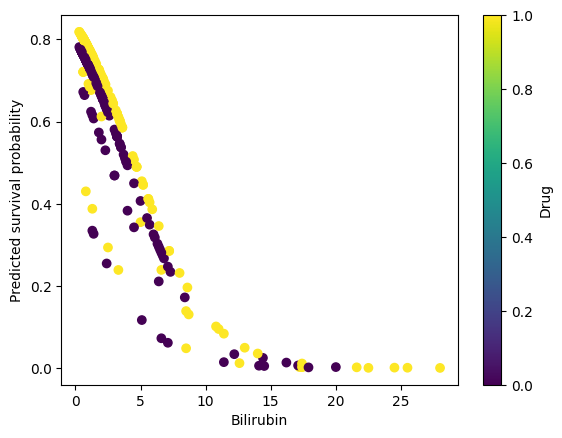

,Predicted survival probability
Drug_Placebo,
False,NaN
True,0.018849


In [ ]:
df_encoded['Predicted survival probability'] = model.predict_proba(df_encoded)[:, 0]
plt.scatter(df_encoded['Bilirubin'], df_encoded['Predicted survival probability'], c = df_encoded['Drug_Placebo'])
plt.xlabel('Bilirubin')
plt.ylabel('Predicted survival probability')
plt.colorbar(label = 'Drug')
plt.show()

df_encoded.groupby('Drug_Placebo')['Predicted survival probability'].mean().diff()

#The drug increases patient survival rate at Billirubin values from 0 to 5
#On average, patients on the placebo have a 1.88 percentage point higher survival probability than those on the drug, which suggests the drug is not improving survival



Q4: Use .predict and compute a confusion matrix for your classifier. What is the accuracy?

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

columns_encoded = ['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo']

y_pred = model.predict(df_encoded[columns_encoded])
print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

#The accuracy is 73.7%

[[171  16]
 [ 66  59]]
0.7371794871794872


Q5: Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

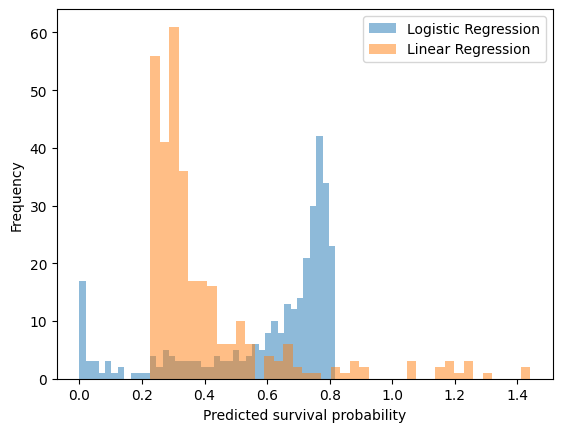

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df_encoded[columns_encoded], y)
df_encoded['Predicted survival probability linear'] = model.predict(df_encoded[columns_encoded])

#Histogram
plt.hist(df_encoded['Predicted survival probability'], bins = 40, alpha = 0.5, label = 'Logistic Regression')
plt.hist(df_encoded['Predicted survival probability linear'], bins = 40, alpha = 0.5, label = 'Linear Regression')
plt.legend()
plt.xlabel('Predicted survival probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#Logistic regression predictions have a bimodal distribution with one centered around zero and the other around 0.7 predicted survival probability
#The linear regression has unrealistic probabilities that are above one. The greatest frequency of observations are at 0.3 predicted survival probabilitity

Q6: Run a logistic regression of Stage on Edema and Bilirubin. Use .predict to make a hard classification, and compute a confusion matrix. Describe your results. Use .predict_proba to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [ ]:
X = ['Edema', 'Bilirubin']
y = df['Stage']

df_encoded = pd.get_dummies(df[X], drop_first = True)
multi_model = LogisticRegression(multi_class = 'multinomial', solver = 'lbfgs')
multi_model.fit(df_encoded, y)

y_pred = multi_model.predict(df_encoded)
print(confusion_matrix(y, y_pred, labels = multi_model.classes_))

Predicted_probabilities = pd.DataFrame(multi_model.predict_proba(df_encoded), columns = multi_model.classes_)
print(Predicted_probabilities)

#The model does not predict stage 1 or 2, it keeps defaulting to 3 and 4, with the majority of predictions being for stage 3
#Thus, hard classification does not predict every class, it only predicts stages 3 and 4 as seen in the confusion matrix

#My predicted probabilities do predict every class as seen by each of the predictions have a probability that is not zero, even though stages 1 and 2 are still not considered the most likely class, at least they are being considered in my model

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
          1.0       2.0       3.0       4.0
0    0.000013  0.032535  0.143611  0.823841
1    0.072394  0.251555  0.397520  0.278531
2    0.029263  0.181531  0.395694  0.393512
3    0.023272  0.176777  0.397217  0.402734
4    0.020204  0.224965  0.423342  0.331488
..        ...       ...       ...       ...
307  0.104545  0.254865  0.381901  0.258689
308  0.104545  0.254865  0.381901  0.258689
309  0.052323  0.246352  0.407444  0.293882
310  0.044365  0.243148  0.411411  0.301076
311  0.003561  0.181092  0.427967  0.387380

[312 rows x 4 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

IMG_7175.heic